In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demesdraw
import demes

import matplotlib, matplotlib.pylab as plt
plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [2]:
# Load best-fit models and data

u = 1.3e-8

graph_alt = "results/basal_eurasian_model_alt_Bherer_2.yaml"
graph_vin = "results/basal_eurasian_model_vin_Bherer_7.yaml"
graph_chag = "results/basal_eurasian_model_chag_Bherer_1.yaml"

data_file = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data_chag = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_chag, return_dict=True)
data_vin = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_vin, return_dict=True)
data_alt= dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_alt, return_dict=True)

model_alt = dpluspy.inference.compute_bin_stats(graph_alt, 
    sampled_demes=data_alt["pop_ids"], bins=data_alt["bins"], u=u)
model_chag = dpluspy.inference.compute_bin_stats(graph_chag, 
    sampled_demes=data_chag["pop_ids"], bins=data_chag["bins"], u=u)
model_vin = dpluspy.inference.compute_bin_stats(graph_vin, 
    sampled_demes=data_vin["pop_ids"], bins=data_vin["bins"], u=u)

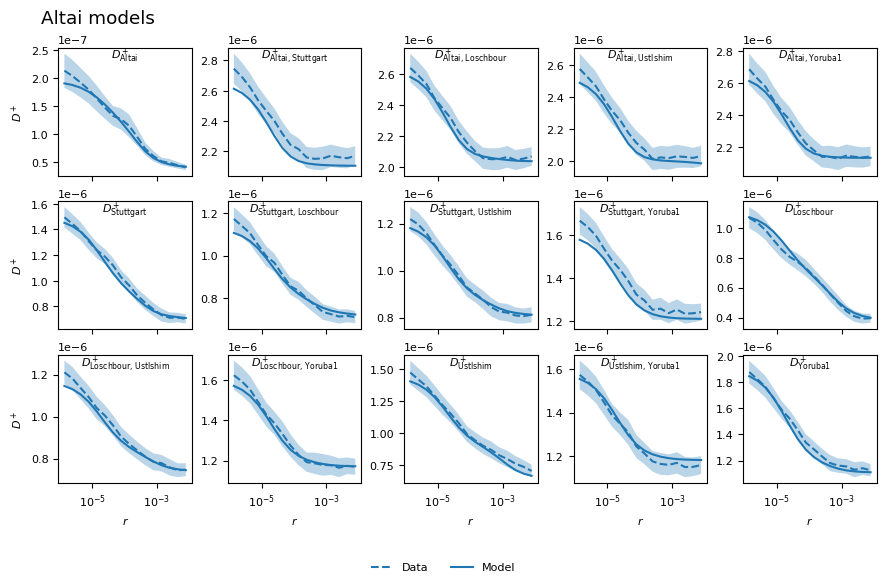

In [3]:
dpluspy.plotting.plot_D_plus_curves(
    models=model_alt,
    pop_ids=data_alt["pop_ids"], 
    bins=data_alt["bins"], 
    means=data_alt["means"], 
    varcovs=data_alt["varcovs"], 
    title="Altai models",
    out="figures/best_fit_altai.pdf",
    ax_size=1.75
)

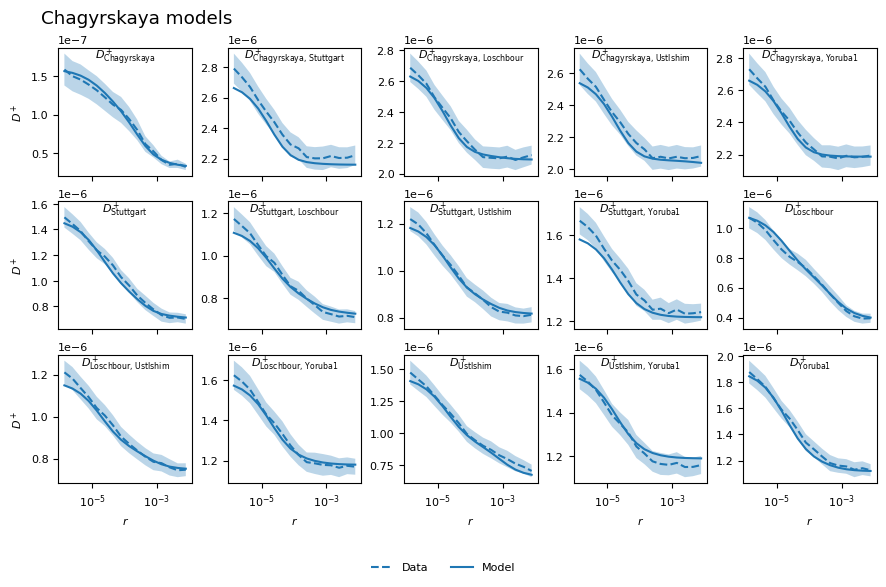

In [4]:
dpluspy.plotting.plot_D_plus_curves(
    models=model_chag,
    pop_ids=data_chag["pop_ids"], 
    bins=data_chag["bins"], 
    means=data_chag["means"], 
    varcovs=data_chag["varcovs"], 
    title="Chagyrskaya models",
    out="figures/best_fit_chagyrskaya.pdf",
    ax_size=1.75
)

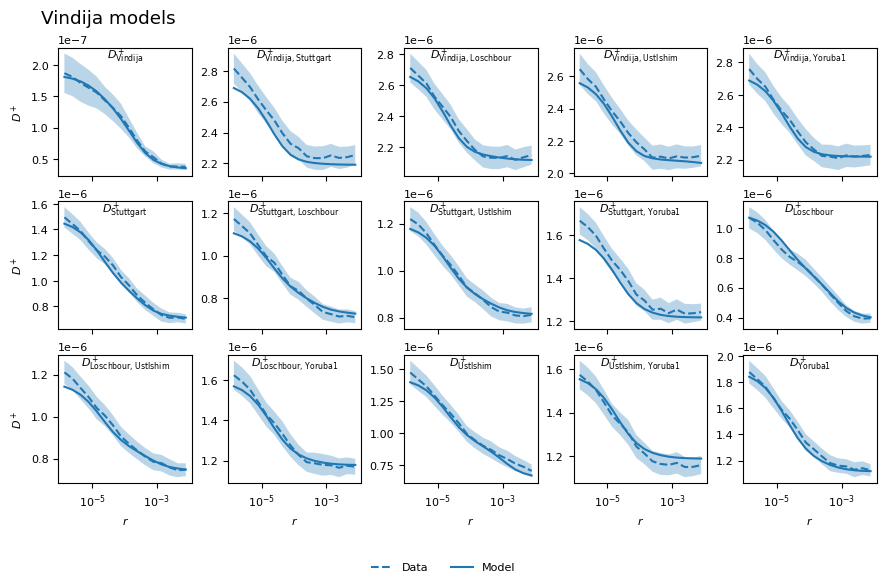

In [5]:
dpluspy.plotting.plot_D_plus_curves(
    models=model_vin,
    pop_ids=data_vin["pop_ids"], 
    bins=data_vin["bins"], 
    means=data_vin["means"], 
    varcovs=data_vin["varcovs"], 
    title="Vindija models",
    out="figures/best_fit_vindija.pdf",
    ax_size=1.75
)

In [6]:
graphs = [
    "results/null_model_chag_Bherer_4.yaml",
    "results/null_model_vin_Bherer_8.yaml",
    "results/marg_model_chag_Bherer_0.yaml",
    "results/marg_model_vin_Bherer_7.yaml",
    "results/admix_model_chag_Bherer_3.yaml",
    "results/admix_model_vin_Bherer_5.yaml"
]
params = [
    "models/null_model_chag_params.yaml",
    "models/null_model_vin_params.yaml",
    "models/marg_model_chag_params.yaml",
    "models/marg_model_vin_params.yaml",
    "models/admix_model_chag_params.yaml",
    "models/admix_model_vin_params.yaml",
]

dfs = []

for graph, params in zip(graphs, params):
    pnames, params = dpluspy.inference._load_params(graph, params)
    pdict = {"model": graph}
    pdict.update({pname: [p] for pname, p in zip(pnames, params)})
    dfs.append(pandas.DataFrame(pdict))

param_df = pandas.concat(dfs)

FileNotFoundError: [Errno 2] No such file or directory: 'results/null_model_chag_Bherer_4.yaml'

In [ ]:
param_df.to_csv("MLE_parameters.csv")
print(param_df.to_string())

                                    model           T_NH         T_OOA         T_Ust      T_LosStu  p_AMH_Cha      m_StuYor  m_LosYor         N_Anc          N_N         N_AMH         N_Yor        N_OOA       N_WEUA         N_Stu        N_Ust         N_Los       T_Basal    T_Bas_Stu  p_Bas_Stu        N_BEUA
0   results/null_model_chag_Bherer_4.yaml  780284.290567  70016.447144  47779.855986  17582.069009   0.074115  1.586601e-04  0.000066  15711.922240  2442.323300  28202.670262  19516.765161  1480.322799  5711.076158  10000.000000   622.472446    510.210290           NaN          NaN        NaN           NaN
0    results/null_model_vin_Bherer_8.yaml  807082.857351  64513.018542  48652.067592  19618.872873   0.098869  1.481003e-04  0.000056  15514.991596  2351.976324  28394.691806  17706.923789  1037.104653  5546.415196  10000.000000   766.906156    612.616418           NaN          NaN        NaN           NaN
0   results/marg_model_chag_Bherer_0.yaml  775431.425872  57244.287873  4896

: 

: 